In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
df = pd.read_csv('weight_height.csv')

In [25]:
df.head()

,Weight,Height
0,45,150
1,47,152
2,49,155
3,50,157
4,53,160


Text(0, 0.5, 'Height')

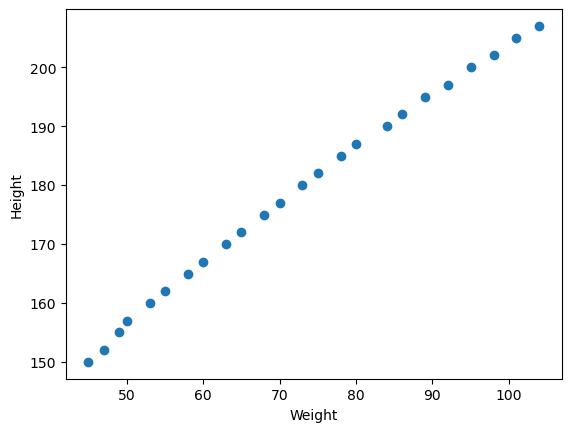

In [26]:
##scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [27]:
## correlation
df.corr()

,Weight,Height
Weight,1.000000,0.998379
Height,0.998379,1.000000


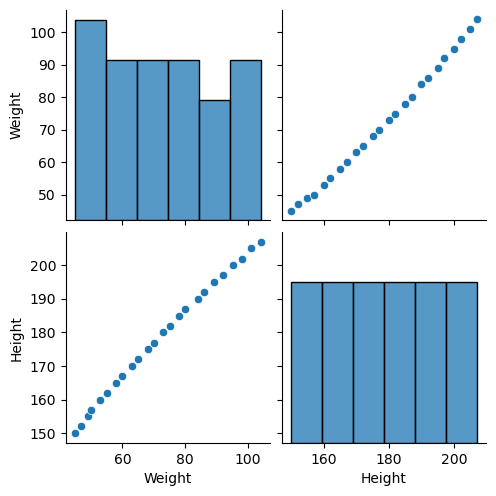

In [28]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [29]:
## Independent and Dependent features
X = df[['Weight']] ## independent feature should be data frame or 2d array
y = df['Height'] ## this variable can be in series or 1d
# np.array(X).shape
y

0     150
1     152
2     155
3     157
4     160
5     162
6     165
7     167
8     170
9     172
10    175
11    177
12    180
13    182
14    185
15    187
16    190
17    192
18    195
19    197
20    200
21    202
22    205
23    207
Name: Height, dtype: int64

In [30]:
# Train Test Split
from sklearn.model_selection import train_test_split

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state=42)

In [32]:
X_train.shape

(18, 1)

In [33]:
## Standardization 
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)

In [35]:
X_test = scaler.transform(X_test)

In [36]:
X_test

array([[-0.55466157],
       [ 0.56056222],
       [-1.51056767],
       [ 0.8260917 ],
       [-0.1829203 ],
       [-0.44844978]])

In [37]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression
reg = LinearRegression(n_jobs=-1)

In [38]:
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [39]:
print("Coefficient or slope: ",reg.coef_)
print("Intercept: ",reg.intercept_)

Coefficient or slope:  [17.96290501]
Intercept:  179.44444444444446


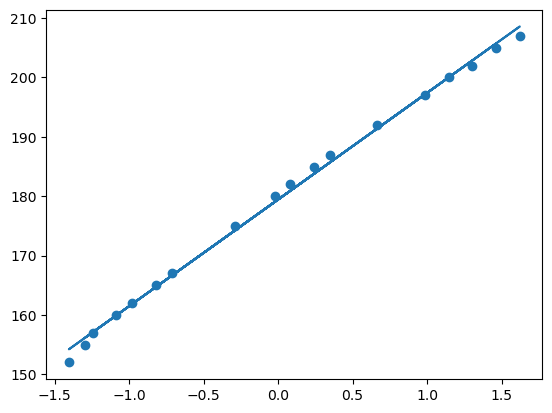

In [40]:
## Plot the Training data best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,reg.predict(X_train))

In [41]:
## prediction for test data 
y_pred=reg.predict(X_test)

In [42]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
8,170,169.481111
16,190,189.513770
0,150,152.310261
18,195,194.283451
11,177,176.158664
9,172,171.388984


In [43]:
## performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [44]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

1.2395997237991516
0.914046632545284
1.113373128739486


In [45]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

0.9942134867664978
